# Complete-Market CVaR Control: Golden Eta Search

This self-contained notebook solves the wealth-only HJB problem with:

- outer bisection for the CVaR multiplier `lambda`;
- inner golden-section minimization for the Rockafellar variable `eta`;
- a one-dimensional finite-difference HJB solver on a 201-point wealth grid;
- four independent plotting cells.

The control is dollar risky exposure, `phi_t = varphi_t S_t`. Stock price is simulated only for the selected market-path diagnostic.


## 1. Imports


In [ ]:
from __future__ import annotations

from dataclasses import dataclass, replace
import math
import time
from typing import Optional

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 180,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.22,
})


## 2. Wealth-Only HJB Solver

For fixed `(lambda, eta)`, the solver uses

```text
V_t + min_phi { gamma*sigma^2*phi^2/2 - mu*phi
                + (r*w + b + mu*phi) V_w
                + (sigma*phi + beta)^2 V_ww/2 } = 0

V(T,w) = lambda * max(-w-eta, 0)/(1-alpha).
```

The bounded quadratic Hamiltonian is minimized analytically. There is no stock-state grid, action grid, eta bisection, safeguard, blending, or comparison solver.


In [ ]:
@dataclass
class ModelParams:
    horizon: float = 1.0
    steps: int = 100
    samples: int = 5000
    seed: int = 7

    w0: float = 1.0
    s0: float = 1.0
    r: float = 0.00
    mu: float = 0.08
    sigma: float = 0.20
    mu_t: Optional[tuple[float, ...]] = None
    sigma_t: Optional[tuple[float, ...]] = None
    b: float = 0.0
    beta: float = 0.0
    price_model: str = "gbm"

    gamma: float = 5.0
    alpha: float = 0.95
    cvar_limit: float = -0.70

    phi_min: float = -2.0
    phi_max: float = 2.0

    eta_tol: float = 1.0e-5
    eta_subgrad_tol: float = 1.0e-5
    lambda_tol: float = 1.0e-4
    residual_tol: float = 1.0e-5
    eta_max_iter: int = 40
    lambda_max_iter: int = 14
    lambda_initial_high: float = 1.0
    lambda_high_cap: float = 1.0e5

    state_grid_size: int = 101
    state_grid_step: Optional[float] = None
    hjb_pde_substeps: int = 8
    hjb_cfl_safety: float = 0.20
    hjb_curvature_floor: float = 1.0e-10
    state_grid_padding: float = 0.25


@dataclass
class ControlResult:
    phi: np.ndarray
    eta: float
    objective: float
    lagrangian: float
    residual: float
    cvar: float
    var: float
    mean_terminal_wealth: float
    terminal_wealth_std: float
    loss_tail_probability: float
    iterations: int
    policy_grid: Optional[np.ndarray] = None
    wealth_grid: Optional[np.ndarray] = None
    terminal_wealth: Optional[np.ndarray] = None
    loss: Optional[np.ndarray] = None
    phi_paths: Optional[np.ndarray] = None
    wealth_paths: Optional[np.ndarray] = None
    stock_paths: Optional[np.ndarray] = None


@dataclass
class CaseResult:
    name: str
    params: ModelParams
    lambda_star: float
    eta_star: float
    objective: float
    cvar: float
    var: float
    residual: float
    rockafellar_residual: float
    terminal_wealth: np.ndarray
    loss: np.ndarray
    phi: np.ndarray
    elapsed_seconds: float
    oracle_calls: int
    mean_terminal_wealth: float
    phi_paths: Optional[np.ndarray] = None
    wealth_paths: Optional[np.ndarray] = None
    stock_paths: Optional[np.ndarray] = None
    policy_grid: Optional[np.ndarray] = None
    wealth_grid: Optional[np.ndarray] = None


def _time_schedule(
    schedule: Optional[tuple[float, ...]], fallback: float, steps: int, name: str
) -> np.ndarray:
    if schedule is None:
        return np.full(steps, float(fallback), dtype=float)
    values = np.asarray(schedule, dtype=float).reshape(-1)
    if values.size == steps + 1:
        values = values[:-1]
    if values.size != steps:
        raise ValueError(
            f"{name} must have length steps or steps + 1; got {values.size} for steps={steps}."
        )
    return values.astype(float, copy=True)


def mu_schedule(params: ModelParams, steps: Optional[int] = None) -> np.ndarray:
    return _time_schedule(params.mu_t, params.mu, params.steps if steps is None else steps, "mu_t")


def sigma_schedule(params: ModelParams, steps: Optional[int] = None) -> np.ndarray:
    return _time_schedule(
        params.sigma_t, params.sigma, params.steps if steps is None else steps, "sigma_t"
    )


def merton_exposure(params: ModelParams) -> np.ndarray:
    mu_t = mu_schedule(params)
    sigma_t = sigma_schedule(params)
    return mu_t / np.maximum(params.gamma * sigma_t**2, 1.0e-12)


def generate_brownian_increments(params: ModelParams) -> np.ndarray:
    rng = np.random.default_rng(params.seed)
    dt = params.horizon / params.steps
    return rng.normal(0.0, math.sqrt(dt), size=(params.samples, params.steps))


def riskless_growth(params: ModelParams, dt: float) -> float:
    return math.exp(params.r * dt)


def stock_gross_return(
    d_brownian: np.ndarray | float,
    mu_n: float,
    sigma_n: float,
    dt: float,
    params: ModelParams,
) -> np.ndarray | float:
    """One-period stock gross return under the selected price model."""
    d_b = np.asarray(d_brownian)
    if params.price_model == "gbm":
        return np.exp((params.r + mu_n - 0.5 * sigma_n**2) * dt + sigma_n * d_b)
    if params.price_model == "euler":
        return riskless_growth(params, dt) + mu_n * dt + sigma_n * d_b
    raise ValueError(f"Unknown price_model={params.price_model!r}")


def stock_excess_return(
    d_brownian: np.ndarray | float,
    mu_n: float,
    sigma_n: float,
    dt: float,
    params: ModelParams,
) -> np.ndarray | float:
    return stock_gross_return(d_brownian, mu_n, sigma_n, dt, params) - riskless_growth(
        params, dt
    )


def simulate_wealth(phi: np.ndarray, d_brownian: np.ndarray, params: ModelParams) -> np.ndarray:
    samples, steps = d_brownian.shape
    dt = params.horizon / steps
    growth = riskless_growth(params, dt)
    mu_t = mu_schedule(params, steps)
    sigma_t = sigma_schedule(params, steps)

    wealth = np.empty((samples, steps + 1))
    wealth[:, 0] = params.w0
    for n in range(steps):
        d_b = d_brownian[:, n]
        risky_excess = stock_excess_return(d_b, mu_t[n], sigma_t[n], dt, params)
        wealth[:, n + 1] = (
            growth * wealth[:, n] + phi[n] * risky_excess + params.b * dt + params.beta * d_b
        )
    return wealth


def cvar_from_loss(loss: np.ndarray, alpha: float) -> tuple[float, float]:
    var = float(np.quantile(loss, alpha))
    cvar = float(var + np.maximum(loss - var, 0.0).mean() / (1.0 - alpha))
    return cvar, var


def lower_tail_wealth_cvar_path(wealth_paths: np.ndarray, alpha: float) -> np.ndarray:
    return np.array([-cvar_from_loss(-wealth_paths[:, n], alpha)[0] for n in range(wealth_paths.shape[1])])


def running_cost(action: np.ndarray | float, params: ModelParams, n: Optional[int] = None) -> np.ndarray | float:
    action_arr = np.asarray(action)
    if n is None:
        if action_arr.ndim > 0 and action_arr.shape[-1] == params.steps:
            shape = (1,) * (action_arr.ndim - 1) + (params.steps,)
            mu_t = mu_schedule(params).reshape(shape)
            sigma_t = sigma_schedule(params).reshape(shape)
            return 0.5 * params.gamma * (sigma_t * action_arr) ** 2 - mu_t * action_arr
        return 0.5 * params.gamma * (params.sigma * action_arr) ** 2 - params.mu * action_arr

    mu_n = mu_schedule(params)[n]
    sigma_n = sigma_schedule(params)[n]
    return 0.5 * params.gamma * (sigma_n * action_arr) ** 2 - mu_n * action_arr


def build_state_grid(d_brownian: np.ndarray, params: ModelParams) -> np.ndarray:
    """Adaptive wealth grid used as the first feedback-state coordinate."""
    probes = [
        np.full(params.steps, params.phi_min),
        np.full(params.steps, params.phi_max),
        np.clip(merton_exposure(params), params.phi_min, params.phi_max),
        np.zeros(params.steps),
    ]
    wealth_paths = [simulate_wealth(phi, d_brownian, params) for phi in probes]
    wealth = np.concatenate([path.reshape(-1) for path in wealth_paths])
    low = float(np.quantile(wealth, 0.002))
    high = float(np.quantile(wealth, 0.998))
    width = max(high - low, 1.0e-3)
    low -= params.state_grid_padding * width
    high += params.state_grid_padding * width
    if params.state_grid_step is not None and params.state_grid_step > 0.0:
        step = float(params.state_grid_step)
        grid_low = step * math.floor(low / step)
        grid_high = step * math.ceil(high / step)
        return np.arange(grid_low, grid_high + 0.5 * step, step)
    return np.linspace(low, high, params.state_grid_size)


def simulate_stock_paths(d_brownian: np.ndarray, params: ModelParams) -> np.ndarray:
    """Simulate stock paths on the same Brownian increments as wealth."""
    samples, steps = d_brownian.shape
    dt = params.horizon / steps
    mu_t = mu_schedule(params, steps)
    sigma_t = sigma_schedule(params, steps)
    stock = np.empty((samples, steps + 1))
    stock[:, 0] = params.s0
    for n in range(steps):
        gross_return = stock_gross_return(
            d_brownian[:, n], mu_t[n], sigma_t[n], dt, params
        )
        stock[:, n + 1] = stock[:, n] * gross_return
    return stock


def linear_interpolate(
    wealth_values: np.ndarray | float,
    wealth_grid: np.ndarray,
    grid_values: np.ndarray,
) -> np.ndarray:
    """Linearly interpolate a value or policy table on the wealth grid."""
    wealth_values = np.asarray(wealth_values, dtype=float)
    wealth_clipped = np.clip(wealth_values, wealth_grid[0], wealth_grid[-1])
    return np.interp(wealth_clipped, wealth_grid, grid_values)


def fit_hjb_policy(
    lambda_value: float,
    eta: float,
    d_brownian: np.ndarray,
    params: ModelParams,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Finite-difference HJB PDE solver for fixed (lambda, eta).

    The HJB state is wealth only. With dollar exposure as the action and
    deterministic return coefficients, neither the wealth dynamics nor the
    objective depends explicitly on the stock-price level.
    """
    wealth_grid = build_state_grid(d_brownian, params)

    dt = params.horizon / params.steps
    mu_t = mu_schedule(params)
    sigma_t = sigma_schedule(params)
    value_next = (
        lambda_value
        * np.maximum(-wealth_grid - eta, 0.0)
        / (1.0 - params.alpha)
    )

    wealth_size = wealth_grid.size
    value_grid = np.empty((params.steps + 1, wealth_size))
    value_grid[-1] = value_next
    policy_grid = np.empty((params.steps, wealth_size))
    edge_order = 2 if wealth_size >= 3 else 1

    def derivatives(value: np.ndarray):
        value_w = np.gradient(
            value, wealth_grid, edge_order=edge_order
        )
        value_ww = np.gradient(
            value_w, wealth_grid, edge_order=edge_order
        )
        return value_w, value_ww

    def hamiltonian(
        action: np.ndarray,
        mu_n: float,
        sigma_n: float,
        value_w: np.ndarray,
        value_ww: np.ndarray,
    ) -> np.ndarray:
        wealth_diffusion = sigma_n * action + params.beta
        return (
            0.5 * params.gamma * (sigma_n * action) ** 2
            - mu_n * action
            + (params.r * wealth_grid + params.b + mu_n * action) * value_w
            + 0.5 * wealth_diffusion**2 * value_ww
        )

    def minimize_hamiltonian(value: np.ndarray, n: int):
        value_w, value_ww = derivatives(value)
        mu_n = float(mu_t[n])
        sigma_n = float(sigma_t[n])

        quadratic = sigma_n**2 * (params.gamma + value_ww)
        linear = (
            mu_n * (value_w - 1.0)
            + sigma_n * params.beta * value_ww
        )
        convex = quadratic > params.hjb_curvature_floor
        interior = np.where(
            convex,
            -linear / np.maximum(quadratic, 1.0e-14),
            0.0,
        )
        interior = np.clip(interior, params.phi_min, params.phi_max)

        best_action = interior
        best_value = hamiltonian(
            interior, mu_n, sigma_n, value_w, value_ww
        )
        lower_action = np.full_like(interior, params.phi_min)
        upper_action = np.full_like(interior, params.phi_max)
        lower_value = hamiltonian(
            lower_action, mu_n, sigma_n, value_w, value_ww
        )
        upper_value = hamiltonian(
            upper_action, mu_n, sigma_n, value_w, value_ww
        )
        use_lower = lower_value < best_value
        best_action = np.where(use_lower, lower_action, best_action)
        best_value = np.where(use_lower, lower_value, best_value)
        use_upper = upper_value < best_value
        best_action = np.where(use_upper, upper_action, best_action)
        best_value = np.where(use_upper, upper_value, best_value)
        return best_action, best_value

    def stable_substeps(n: int) -> int:
        wealth_spacing = float(np.min(np.diff(wealth_grid)))
        sigma_n = abs(float(sigma_t[n]))
        maximum_action = max(abs(params.phi_min), abs(params.phi_max))
        wealth_diffusion = sigma_n * maximum_action + abs(params.beta)
        diffusion_rate = wealth_diffusion**2 / max(
            wealth_spacing**2, 1.0e-14
        )
        cfl_substeps = int(
            math.ceil(
                dt
                * diffusion_rate
                / max(params.hjb_cfl_safety, 1.0e-6)
            )
        )
        return max(params.hjb_pde_substeps, cfl_substeps, 1)

    for n in range(params.steps - 1, -1, -1):
        value = value_next
        substeps = stable_substeps(n)
        sub_dt = dt / substeps
        best_action = np.zeros(wealth_size)
        for _ in range(substeps):
            best_action, minimized_generator = minimize_hamiltonian(value, n)
            value = value + sub_dt * minimized_generator
            if not np.all(np.isfinite(value)):
                raise FloatingPointError(
                    "The explicit HJB step became unstable. Reduce "
                    "hjb_cfl_safety or increase hjb_pde_substeps."
                )

        value_next = value
        value_grid[n] = value_next
        policy_grid[n] = best_action

    return wealth_grid, policy_grid, value_grid


# Backward-compatible name used by plotting and diagnostic cells.
fit_feedback_policy = fit_hjb_policy


def simulate_feedback_policy(
    wealth_grid: np.ndarray,
    policy_grid: np.ndarray,
    d_brownian: np.ndarray,
    params: ModelParams,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Simulate a policy phi_n = f_n(W_n) with linear interpolation."""
    samples, steps = d_brownian.shape
    dt = params.horizon / steps
    growth = riskless_growth(params, dt)
    mu_t = mu_schedule(params, steps)
    sigma_t = sigma_schedule(params, steps)

    wealth = np.empty((samples, steps + 1))
    stock = np.empty((samples, steps + 1))
    phi_paths = np.empty((samples, steps))
    wealth[:, 0] = params.w0
    stock[:, 0] = params.s0

    for n in range(steps):
        phi_n = linear_interpolate(
            wealth[:, n],
            wealth_grid,
            policy_grid[n],
        )
        phi_n = np.clip(phi_n, params.phi_min, params.phi_max)
        phi_paths[:, n] = phi_n

        d_b = d_brownian[:, n]
        risky_excess = stock_excess_return(
            d_b, mu_t[n], sigma_t[n], dt, params
        )
        gross_return = stock_gross_return(
            d_b, mu_t[n], sigma_t[n], dt, params
        )
        wealth[:, n + 1] = (
            growth * wealth[:, n]
            + phi_n * risky_excess
            + params.b * dt
            + params.beta * d_b
        )
        stock[:, n + 1] = stock[:, n] * gross_return

    return wealth, stock, phi_paths


def feedback_value_iteration_kernel(
    lambda_value: float,
    eta: float,
    d_brownian: np.ndarray,
    params: ModelParams,
) -> ControlResult:
    wealth_grid, policy_grid, _ = fit_hjb_policy(
        lambda_value, eta, d_brownian, params
    )
    wealth, stock, phi_paths = simulate_feedback_policy(
        wealth_grid, policy_grid, d_brownian, params
    )

    dt = params.horizon / params.steps
    terminal_wealth = wealth[:, -1]
    loss = -terminal_wealth
    hinge = np.maximum(loss - eta, 0.0)
    running = dt * np.sum(running_cost(phi_paths, params), axis=1)
    objective = float(np.mean(running))
    residual = float(
        eta + hinge.mean() / (1.0 - params.alpha) - params.cvar_limit
    )
    lagrangian = objective + lambda_value * residual
    cvar, var = cvar_from_loss(loss, params.alpha)

    return ControlResult(
        phi=np.mean(phi_paths, axis=0),
        eta=eta,
        objective=objective,
        lagrangian=lagrangian,
        residual=residual,
        cvar=cvar,
        var=var,
        mean_terminal_wealth=float(np.mean(terminal_wealth)),
        terminal_wealth_std=float(np.std(terminal_wealth)),
        loss_tail_probability=float(np.mean(loss > eta)),
        iterations=params.steps,
        policy_grid=policy_grid,
        wealth_grid=wealth_grid,
        terminal_wealth=terminal_wealth,
        loss=loss,
        phi_paths=phi_paths,
        wealth_paths=wealth,
        stock_paths=stock,
    )


def unconstrained_solution(d_brownian: np.ndarray, params: ModelParams) -> ControlResult:
    result = feedback_value_iteration_kernel(0.0, 0.0, d_brownian, params)
    loss = result.loss if result.loss is not None else -result.terminal_wealth
    cvar, var = cvar_from_loss(loss, params.alpha)
    return replace(
        result,
        eta=var,
        residual=cvar - params.cvar_limit,
        cvar=cvar,
        var=var,
        loss_tail_probability=float(np.mean(loss > var)),
        loss=loss,
    )


def eta_bracket(params: ModelParams) -> tuple[float, float]:
    mu_abs_max = float(np.max(np.abs(mu_schedule(params))))
    sigma_abs_max = float(np.max(np.abs(sigma_schedule(params))))
    max_exposure = max(abs(params.phi_min), abs(params.phi_max))
    drift_bound = abs(params.w0) + params.horizon * (
        abs(params.r) * (abs(params.w0) + 4.0) + mu_abs_max * max_exposure + abs(params.b)
    )
    diffusion_bound = 6.0 * math.sqrt(params.horizon) * (sigma_abs_max * max_exposure + abs(params.beta))
    return -max(2.0, drift_bound + diffusion_bound), max(2.0, drift_bound + diffusion_bound)


def eta_golden_search(
    lambda_value: float,
    d_brownian: np.ndarray,
    params: ModelParams,
) -> ControlResult:
    """Golden-section minimization of the Rockafellar Lagrangian over eta."""
    if lambda_value <= 0.0:
        return unconstrained_solution(d_brownian, params)

    eta_low, eta_high = eta_bracket(params)
    rho = (math.sqrt(5.0) - 1.0) / 2.0
    eta1 = eta_high - rho * (eta_high - eta_low)
    eta2 = eta_low + rho * (eta_high - eta_low)
    result1 = feedback_value_iteration_kernel(
        lambda_value, eta1, d_brownian, params
    )
    result2 = feedback_value_iteration_kernel(
        lambda_value, eta2, d_brownian, params
    )

    for _ in range(params.eta_max_iter):
        if eta_high - eta_low <= params.eta_tol:
            break
        if result1.lagrangian <= result2.lagrangian:
            eta_high = eta2
            eta2 = eta1
            result2 = result1
            eta1 = eta_high - rho * (eta_high - eta_low)
            result1 = feedback_value_iteration_kernel(
                lambda_value, eta1, d_brownian, params
            )
        else:
            eta_low = eta1
            eta1 = eta2
            result1 = result2
            eta2 = eta_low + rho * (eta_high - eta_low)
            result2 = feedback_value_iteration_kernel(
                lambda_value, eta2, d_brownian, params
            )

    return (
        result1
        if result1.lagrangian <= result2.lagrangian
        else result2
    )


def _history_row(lambda_value: float, result: ControlResult) -> dict[str, float]:
    return {
        "lambda": float(lambda_value),
        "eta": float(result.eta),
        "residual": float(result.residual),
        "objective": float(result.objective),
        "cvar": float(result.cvar),
    }


def constraint_residual(
    result: ControlResult,
    params: ModelParams,
) -> float:
    """Empirical terminal loss-CVaR residual used by the lambda search."""
    return float(result.cvar - params.cvar_limit)


def outer_bisection(
    d_brownian: np.ndarray,
    params: ModelParams,
) -> tuple[ControlResult, float, list[dict[str, float]]]:
    """Outer bisection for the smallest feasible lambda."""
    history: list[dict[str, float]] = []
    unconstrained = unconstrained_solution(d_brownian, params)
    history.append(_history_row(0.0, unconstrained))
    if constraint_residual(unconstrained, params) <= 0.0:
        return unconstrained, 0.0, history

    lambda_low = 0.0
    lambda_high = params.lambda_initial_high
    high_result = eta_golden_search(
        lambda_high, d_brownian, params
    )
    history.append(_history_row(lambda_high, high_result))

    while constraint_residual(high_result, params) > 0.0:
        lambda_low = lambda_high
        lambda_high *= 2.0
        if lambda_high > params.lambda_high_cap:
            raise RuntimeError(
                "Failed to bracket a feasible multiplier."
            )
        high_result = eta_golden_search(
            lambda_high, d_brownian, params
        )
        history.append(_history_row(lambda_high, high_result))

    best_feasible = high_result
    best_lambda = lambda_high
    for _ in range(params.lambda_max_iter):
        lambda_mid = 0.5 * (lambda_low + lambda_high)
        mid_result = eta_golden_search(
            lambda_mid, d_brownian, params
        )
        history.append(_history_row(lambda_mid, mid_result))
        mid_residual = constraint_residual(mid_result, params)

        if -params.residual_tol <= mid_residual <= 0.0:
            return mid_result, lambda_mid, history
        if mid_residual > 0.0:
            lambda_low = lambda_mid
        else:
            lambda_high = lambda_mid
            best_feasible = mid_result
            best_lambda = lambda_mid
        if lambda_high - lambda_low <= params.lambda_tol:
            break

    return best_feasible, best_lambda, history


def solve_case(name: str, params: ModelParams) -> CaseResult:
    started = time.perf_counter()
    d_brownian = generate_brownian_increments(params)
    result, lambda_star, history = outer_bisection(d_brownian, params)
    terminal_wealth = result.terminal_wealth
    loss = result.loss if result.loss is not None else -terminal_wealth
    cvar, var = cvar_from_loss(loss, params.alpha)
    return CaseResult(
        name=name,
        params=params,
        lambda_star=lambda_star,
        eta_star=result.eta,
        objective=result.objective,
        cvar=cvar,
        var=var,
        residual=cvar - params.cvar_limit,
        rockafellar_residual=result.residual,
        terminal_wealth=terminal_wealth,
        loss=loss,
        phi=result.phi,
        elapsed_seconds=time.perf_counter() - started,
        oracle_calls=len(history),
        mean_terminal_wealth=float(np.mean(terminal_wealth)),
        phi_paths=result.phi_paths,
        wealth_paths=result.wealth_paths,
        policy_grid=result.policy_grid,
        wealth_grid=result.wealth_grid,
        stock_paths=result.stock_paths,
    )


def summarize_case(case: CaseResult) -> dict[str, float | str]:
    phi_values = case.phi_paths if case.phi_paths is not None else case.phi[None, :]
    return {
        "case": case.name,
        "lambda*": case.lambda_star,
        "E[W_T]": float(np.mean(case.terminal_wealth)),
        "std(W_T)": float(np.std(case.terminal_wealth)),
        "wealth tail CVaR": -case.cvar,
        "floor -c": -case.params.cvar_limit,
        "slack c-CVaR": case.params.cvar_limit - case.cvar,
        "mean phi=varphi*S": float(np.mean(phi_values)),
        "min phi": float(np.min(phi_values)),
        "max phi": float(np.max(phi_values)),
        "runtime sec": case.elapsed_seconds,
    }


def print_summary_table(cases: list[CaseResult]) -> None:
    rows = [summarize_case(case) for case in cases]
    headers = ["case", "lambda*", "E[W_T]", "wealth tail CVaR", "floor -c", "mean phi=varphi*S", "runtime sec"]
    print(" | ".join(headers))
    print(" | ".join("-" * len(h) for h in headers))
    for row in rows:
        values = []
        for header in headers:
            value = row[header]
            values.append(f"{value:.4f}" if isinstance(value, float) else str(value))
        print(" | ".join(values))


## 3. Settings


In [ ]:
BASE_PARAMS = ModelParams(
    horizon=1.0,
    steps=100,
    samples=5000,
    seed=7,
    w0=1.0,
    s0=1.0,
    r=0.0,
    mu=0.08,
    sigma=0.20,
    b=0.0,
    beta=0.0,
    price_model="gbm",
    gamma=5.0,
    alpha=0.95,
    phi_min=-2.0,
    phi_max=2.0,
    cvar_limit=-0.86,
    eta_tol=1.0e-5,
    lambda_tol=1.0e-5,
    residual_tol=1.0e-5,
    eta_max_iter=100,
    lambda_max_iter=24,
    lambda_initial_high=1.0,
    lambda_high_cap=1.0e5,
    state_grid_size=201,
    state_grid_step=None,
    state_grid_padding=0.25,
    hjb_pde_substeps=8,
    hjb_cfl_safety=0.20,
    hjb_curvature_floor=1.0e-10,
)

CASE_PARAMS = {
    "inactive": replace(BASE_PARAMS, cvar_limit=-0.86, seed=11),
    "active": replace(BASE_PARAMS, cvar_limit=-0.94, seed=13),
}

time_grid = np.linspace(
    0.0, BASE_PARAMS.horizon, BASE_PARAMS.steps + 1
)
merton_line = merton_exposure(BASE_PARAMS)

print(f"searches: outer lambda bisection, inner eta golden section")
print(f"HJB state: wealth only, {BASE_PARAMS.state_grid_size} points")
print(f"time steps: {BASE_PARAMS.steps}, paths: {BASE_PARAMS.samples}")
print(f"r = {BASE_PARAMS.r:.4f}, Merton exposure = {merton_line[0]:.4f}")


searches: outer lambda bisection, inner eta golden section
HJB state: wealth only, 201 points
time steps: 100, paths: 5000
r = 0.0000, Merton exposure = 0.4000


## 4. Run Active And Inactive Cases


In [ ]:
cases = [
    solve_case("inactive", CASE_PARAMS["inactive"]),
    solve_case("active", CASE_PARAMS["active"]),
]

print_summary_table(cases)

active_case = next(case for case in cases if case.name == "active")
print(f"active eta*: {active_case.eta_star:.9f}")
print(f"active wealth-tail CVaR: {-active_case.cvar:.9f}")
print(f"active floor: {-active_case.params.cvar_limit:.9f}")
print(f"active empirical residual: {active_case.residual:+.3e}")


case | lambda* | E[W_T] | wealth tail CVaR | floor -c | mean phi=varphi*S | runtime sec
---- | ------- | ------ | ---------------- | -------- | ----------------- | -----------
inactive | 0.0000 | 1.0323 | 0.8690 | 0.8600 | 0.4000 | 2.7021
active | 0.0666 | 1.0242 | 0.9400 | 0.9400 | 0.3001 | 783.7727
active eta*: -0.946176566
active wealth-tail CVaR: 0.940002476
active floor: 0.940000000
active empirical residual: -2.476e-06


## 5. Shared Plot Helpers


In [ ]:
CASE_COLORS = {
    "inactive": "#2563eb",
    "active": "#dc2626",
}
CASE_LABELS = {
    "inactive": "inactive",
    "active": "active",
}


def gaussian_kde_1d(samples, grid, bandwidth=None):
    samples = np.asarray(samples, dtype=float)
    if bandwidth is None:
        scale = max(float(np.std(samples, ddof=1)), 1.0e-8)
        bandwidth = max(
            1.06 * scale * samples.size ** (-0.2),
            1.0e-4,
        )
    z = (grid[:, None] - samples[None, :]) / bandwidth
    return np.exp(-0.5 * z * z).mean(axis=1) / (
        bandwidth * np.sqrt(2.0 * np.pi)
    )


def simulate_case_paths(case, path_count, seed_shift):
    params = replace(
        case.params,
        samples=path_count,
        seed=case.params.seed + seed_shift,
    )
    d_brownian = generate_brownian_increments(params)
    return simulate_feedback_policy(
        case.wealth_grid,
        case.policy_grid,
        d_brownian,
        params,
    )


## Plot 1. Terminal Wealth Distribution


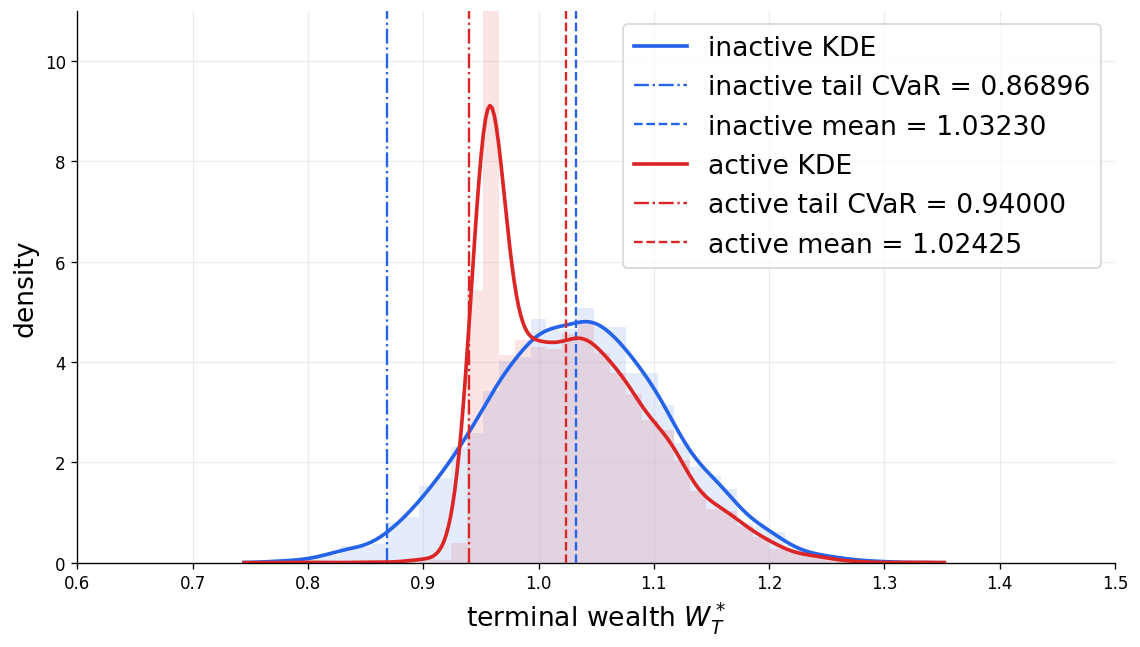

In [ ]:
def plot_terminal_wealth_distribution(
    cases,
    bins_count=44,
    figsize=(9.6, 5.5),
    save_path=None,
):
    all_wealth = np.concatenate(
        [case.terminal_wealth for case in cases]
    )
    padding = 0.04 * max(float(np.ptp(all_wealth)), 1.0e-3)
    grid = np.linspace(
        all_wealth.min() - padding,
        all_wealth.max() + padding,
        320,
    )
    bins = np.linspace(grid[0], grid[-1], bins_count + 1)
    fig, ax = plt.subplots(figsize=figsize)

    for case in cases:
        color = CASE_COLORS[case.name]
        label = CASE_LABELS[case.name]
        ax.hist(
            case.terminal_wealth,
            bins=bins,
            density=True,
            color=color,
            alpha=0.12,
            edgecolor="none",
        )
        ax.plot(
            grid,
            gaussian_kde_1d(case.terminal_wealth, grid),
            color=color,
            linewidth=2.2,
            label=f"{label} KDE",
        )
        ax.axvline(
            -case.cvar,
            color=color,
            linestyle="-.",
            linewidth=1.4,
            label=f"{label} tail CVaR = {-case.cvar:.5f}",
        )
        terminal_mean = float(np.mean(case.terminal_wealth))
        ax.axvline(
            terminal_mean,
            color=color,
            linestyle="--",
            linewidth=1.4,
            label=f"{label} mean = {terminal_mean:.5f}",
        )

    ax.set_xlabel(r"terminal wealth $W_T^*$",fontsize=16)
    ax.set_ylabel("density",fontsize=16)
    ax.set_xlim(0.6,1.5)
    ax.set_ylim(0.0, 11.0)
    ax.legend(loc="upper right", frameon=True,fontsize=16)
    fig.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight")
    return fig, ax


fig_terminal, ax_terminal = plot_terminal_wealth_distribution(cases)



## Plot 2. Dollar Risky Exposure


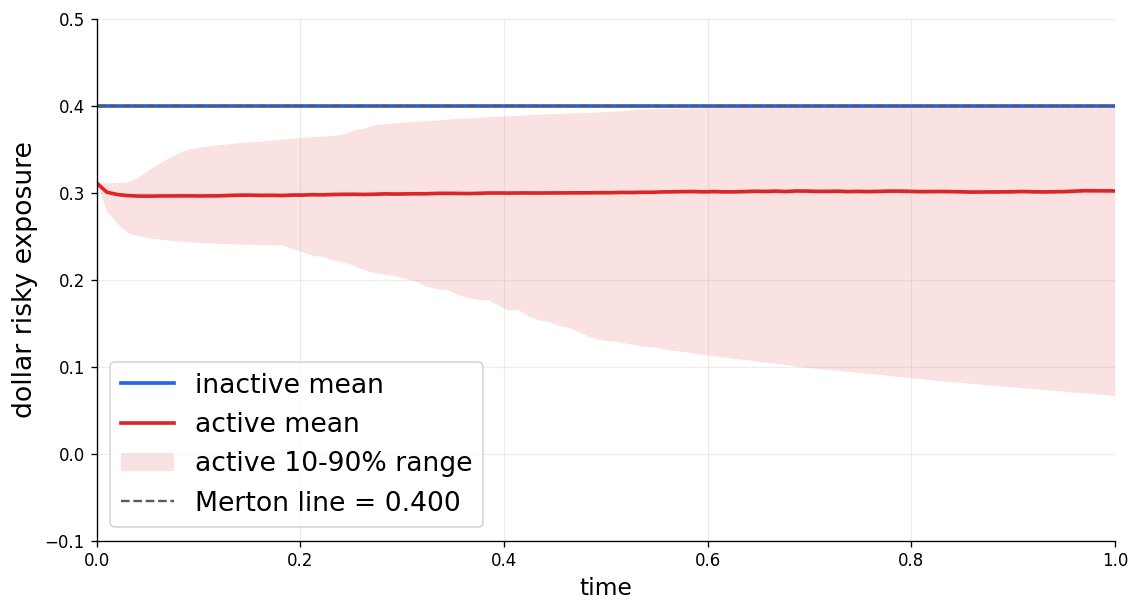

In [ ]:
def plot_exposure_trajectory(
    cases,
    figsize=(9.6, 5.2),
    save_path=None,
):
    t = np.linspace(
        0.0, BASE_PARAMS.horizon, BASE_PARAMS.steps
    )
    fig, ax = plt.subplots(figsize=figsize)

    for case in cases:
        color = CASE_COLORS[case.name]
        label = CASE_LABELS[case.name]
        mean_phi = np.mean(case.phi_paths, axis=0)
        ax.plot(
            t,
            mean_phi,
            color=color,
            linewidth=2.2,
            label=f"{label} mean",
        )
        if case.name == "active":
            q10, q90 = np.quantile(
                case.phi_paths, [0.10, 0.90], axis=0
            )
            ax.fill_between(
                t,
                q10,
                q90,
                color=color,
                alpha=0.13,
                linewidth=0,
                label="active 10-90% range",
            )

    ax.axhline(
        float(merton_line[0]),
        color="0.35",
        linestyle="--",
        linewidth=1.4,
        label=f"Merton line = {merton_line[0]:.3f}",
    )
    ax.set_xlim(0.0, BASE_PARAMS.horizon)
    ax.set_ylim(-0.1, 0.5)
    ax.set_xlabel("time", fontsize=14)
    ax.set_ylabel("dollar risky exposure", fontsize=16)
    ax.legend(loc="best", frameon=True, fontsize=16)
    fig.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight")
    return fig, ax


fig_control, ax_control = plot_exposure_trajectory(cases)


## Plot 3. Wealth CVaR Over Time


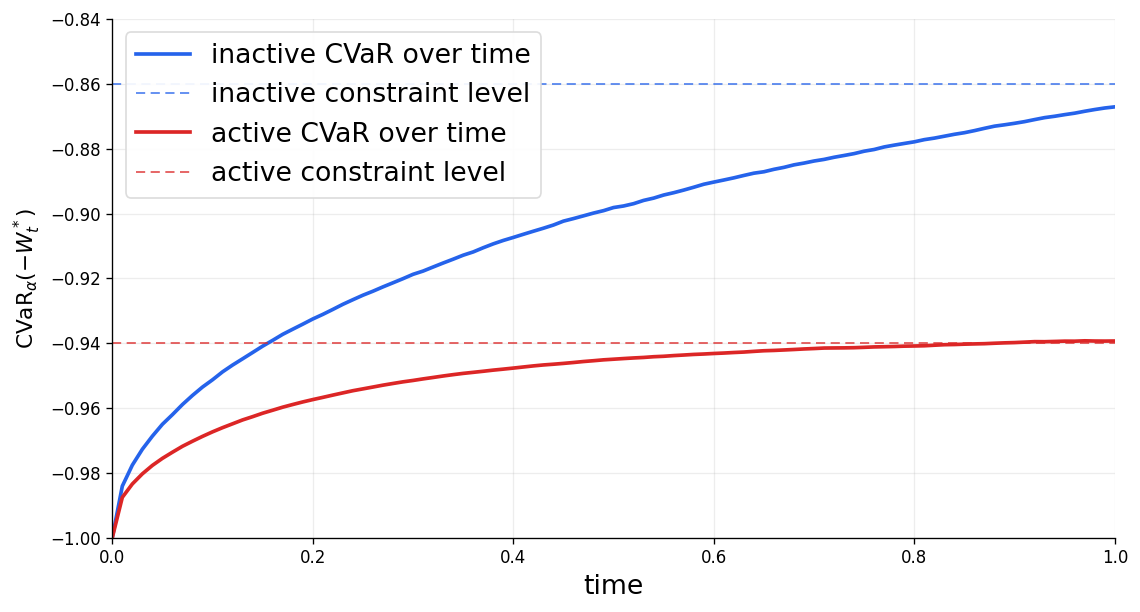

In [ ]:
def resimulate_case_wealth_paths(case, plot_samples=5000, seed_shift=100000):
    plot_params = replace(
        case.params,
        samples=plot_samples,
        seed=case.params.seed + seed_shift,
    )
    d_brownian = generate_brownian_increments(plot_params)
    wealth_paths, _, _ = simulate_feedback_policy(
        case.wealth_grid,
        case.policy_grid,
        d_brownian,
        plot_params,
    )
    return wealth_paths


def plot_wealth_cvar_over_time(
    cases,
    plot_samples=None,
    terminal_tolerance=2.0e-3,
    figsize=(9.6, 5.2),
    save_path=None,
):
    fig, ax = plt.subplots(figsize=figsize)
    for case in cases:
        color = CASE_COLORS.get(case.name, "black")
        label = CASE_LABELS.get(case.name, case.name)
        if plot_samples is None:
            wealth_paths = case.wealth_paths
        else:
            wealth_paths = resimulate_case_wealth_paths(
                case,
                plot_samples=plot_samples,
            )

        wealth_cvar = lower_tail_wealth_cvar_path(
            wealth_paths,
            case.params.alpha,
        )
        plot_terminal_cvar = wealth_cvar[-1]
        solver_terminal_cvar = -case.cvar
        terminal_floor = -case.params.cvar_limit
        terminal_gap = abs(
            plot_terminal_cvar - solver_terminal_cvar
        )
        if terminal_gap > terminal_tolerance:
            print(
                f"warning: {case.name} plot terminal CVaR differs "
                f"from solver by {terminal_gap:.6f}; use "
                "plot_samples=None to plot solver paths exactly."
            )

        t = np.linspace(
            0.0,
            case.params.horizon,
            wealth_cvar.size,
        )
        ax.plot(
            t,
            -wealth_cvar,
            color=color,
            linewidth=2.2,
            label=f"{label} CVaR over time",
        )
        ax.axhline(
            -terminal_floor,
            color=color,
            linewidth=1.1,
            linestyle=(0, (5, 3)),
            alpha=0.75,
            label=f"{label} constraint level",
        )

    ax.set_xlabel("time", fontsize=16)
    ax.set_ylabel(r"CVaR$_\alpha(-W_t^*)$", fontsize=13)
    ax.set_xlim(0.0, BASE_PARAMS.horizon)
    ax.set_ylim(-1.0, -0.84)
    ax.legend(
        loc="upper left",
        frameon=True,
        framealpha=0.92,
        edgecolor="0.85",
        fontsize=16,
    )
    fig.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight")
    return fig, ax


fig_cvar_time, ax_cvar_time = plot_wealth_cvar_over_time(
    cases,
    plot_samples=100000,
)


## Plot 4. Selected Good And Bad Market Paths


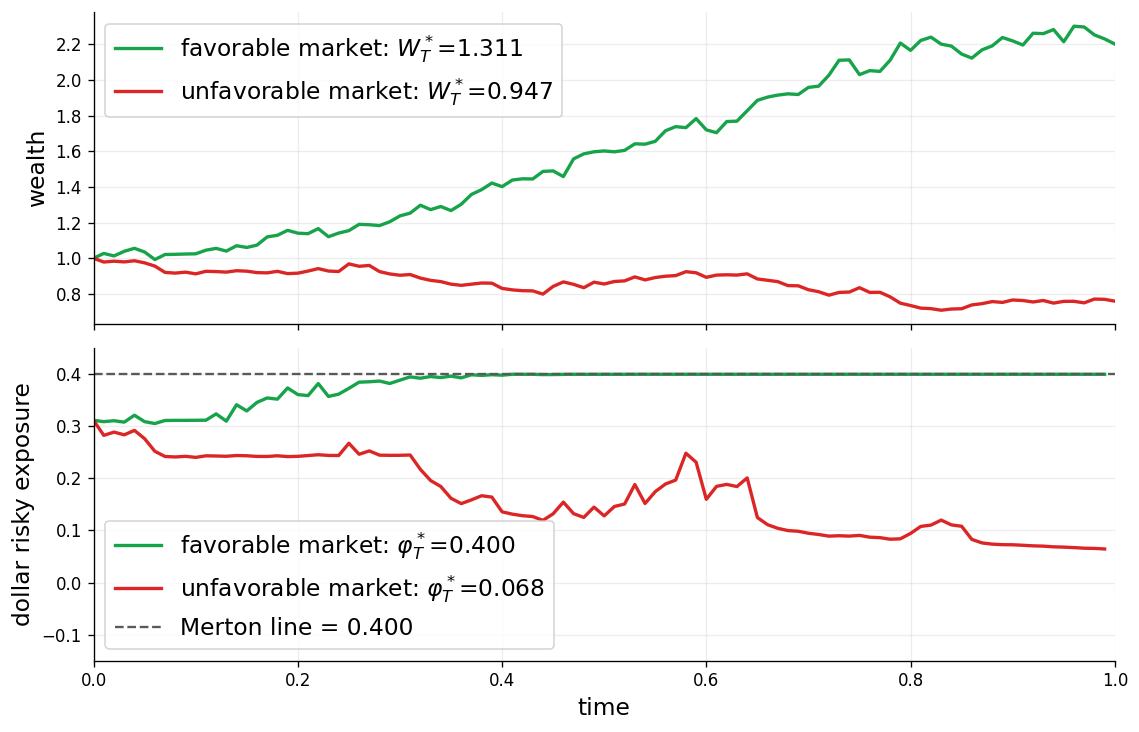

In [ ]:
def select_good_bad_paths(
    stock_paths,
    phi_paths,
    merton_value,
    maturity_window=10,
):
    terminal_stock = stock_paths[:, -1]
    late_phi = phi_paths[:, -maturity_window:].mean(axis=1)

    good_pool = np.where(
        terminal_stock >= np.quantile(terminal_stock, 0.75)
    )[0]
    bad_pool = np.where(
        terminal_stock <= np.quantile(terminal_stock, 0.25)
    )[0]
    good_idx = good_pool[
        np.argmin(np.abs(late_phi[good_pool] - merton_value))
    ]
    bad_idx = bad_pool[np.argmin(late_phi[bad_pool])]
    return int(good_idx), int(bad_idx)


def plot_good_bad_market_paths(
    active_case,
    path_count=8000,
    maturity_window=10,
    figsize=(9.6, 6.2),
    save_path=None,
):
    wealth, stock, phi_paths = simulate_case_paths(
        active_case,
        path_count=path_count,
        seed_shift=250000,
    )
    merton_value = float(merton_exposure(active_case.params)[-1])
    good_idx, bad_idx = select_good_bad_paths(
        stock,
        phi_paths,
        merton_value,
        maturity_window=maturity_window,
    )
    t_stock = np.linspace(
        0.0,
        active_case.params.horizon,
        active_case.params.steps + 1,
    )
    t_phi = t_stock[:-1]
    fig, (ax_stock, ax_phi) = plt.subplots(
        2, 1, figsize=figsize, sharex=True
    )

    for index, color, label in [
        (good_idx, "#16a34a", "favorable market"),
        (bad_idx, CASE_COLORS["active"], "unfavorable market"),
    ]:
        late_phi = float(
            phi_paths[index, -maturity_window:].mean()
        )
        ax_stock.plot(
            t_stock,
            stock[index],
            color=color,
            linewidth=2.0,
            label=f"{label}: $W_T^*$={wealth[index, -1]:.3f}",
        )
        ax_phi.plot(
            t_phi,
            phi_paths[index],
            color=color,
            linewidth=2.0,
            label=fr"{label}: $\varphi_T^*$={late_phi:.3f}",
        )

    ax_phi.axhline(
        merton_value,
        color="0.35",
        linestyle="--",
        linewidth=1.4,
        label=f"Merton line = {merton_value:.3f}",
    )
    ax_stock.set_ylabel("wealth", fontsize=14)
    ax_phi.set_ylabel(r"dollar risky exposure", fontsize=14)
    ax_phi.set_xlabel("time", fontsize=14)
    ax_phi.set_xlim(0.0, BASE_PARAMS.horizon)
    ax_stock.set_xlim(0.0, BASE_PARAMS.horizon)
    ax_phi.set_ylim(-0.15, 0.45)
    ax_stock.legend(loc="upper left", frameon=True, fontsize=14)
    ax_phi.legend(loc="lower left", frameon=True, fontsize=14)
    fig.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight")
    return fig, (ax_stock, ax_phi), (good_idx, bad_idx)


active_case = next(case for case in cases if case.name == "active")
fig_paths, axes_paths, selected_paths = plot_good_bad_market_paths(
    active_case
)
